# FER2013 Data Exploration

Use this notebook in Colab or Kaggle to inspect FER2013 before training. The goal is not only to show the dataset, but to use the dataset properties as evidence for the modeling protocol: why we need augmentation, imbalance handling, per-class F1, confusion matrices, and a ResNet18 transfer-learning baseline.


## 1. Setup

Upload or mount the repository, then update `PROJECT_ROOT` and `DATA_DIR` if needed.


In [61]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

# Local path after extracting Kaggle data:
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'fer2013_images'

# Kaggle example, uncomment and edit if needed:
# DATA_DIR = Path('/kaggle/input/msambare/fer2013')

DATA_DIR


WindowsPath('d:/Deep-Learning/DL-final-project/data/raw/fer2013_images')

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from fer_project.data import EMOTION_LABELS, folder_class_to_fer_label


## 2. Load FER2013 Image Folders

FER2013 is stored as image folders with seven emotion labels. We first verify the train/test split sizes and class counts because the rest of the project should be evaluated under the same protocol. The training notebook later creates a validation split from the training folder for model selection.


In [63]:
rows = []
for split in ['train', 'test']:
    split_dir = DATA_DIR / split
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = folder_class_to_fer_label(class_dir.name)
        image_paths = list(class_dir.glob('*'))
        rows.append({
            'split': split,
            'emotion': label,
            'emotion_name': EMOTION_LABELS[label],
            'folder': class_dir.name,
            'count': len(image_paths),
        })

counts = pd.DataFrame(rows).sort_values(['split', 'emotion'])
counts


,split,emotion,emotion_name,folder,count
7,test,0,angry,angry,958
8,test,1,disgust,disgust,111
9,test,2,fear,fear,1024
10,test,3,happy,happy,1774
12,test,4,sad,sad,1247
13,test,5,surprise,surprise,831
11,test,6,neutral,neutral,1233
0,train,0,angry,angry,3995
1,train,1,disgust,disgust,436
2,train,2,fear,fear,4097


In [64]:
split_totals = counts.groupby('split')['count'].sum()
class_count_table = counts.pivot_table(index='emotion_name', columns='split', values='count', fill_value=0)
split_totals.to_frame(name='count')
class_count_table


split,test,train
emotion_name,,
angry,958.0,3995.0
disgust,111.0,436.0
fear,1024.0,4097.0
happy,1774.0,7215.0
neutral,1233.0,4965.0
sad,1247.0,4830.0
surprise,831.0,3171.0


## 3. Class Distribution and Imbalance

The class distribution is the first modeling clue. FER2013 is not balanced: emotions such as `happy` usually have many more samples than `disgust`. This means accuracy alone can hide weak performance on minority classes, so the report must use macro F1, weighted F1, per-class precision/recall/F1, and confusion matrices.


In [65]:
distribution = counts.copy()
distribution['split_total'] = distribution.groupby('split')['count'].transform('sum')
distribution['percentage'] = 100 * distribution['count'] / distribution['split_total']
percentage_table = distribution.pivot_table(index='emotion_name', columns='split', values='percentage', fill_value=0).round(2)
percentage_table


split,test,train
emotion_name,,
angry,13.35,13.92
disgust,1.55,1.52
fear,14.27,14.27
happy,24.71,25.13
neutral,17.18,17.29
sad,17.37,16.82
surprise,11.58,11.05


In [66]:
train_counts = counts[counts['split'] == 'train'].set_index('emotion_name')['count'].sort_values(ascending=False)
imbalance_summary = pd.DataFrame({
    'train_count': train_counts,
    'train_percentage': (100 * train_counts / train_counts.sum()).round(2),
})
imbalance_ratio = train_counts.max() / train_counts.min()
imbalance_summary.attrs['imbalance_ratio'] = imbalance_ratio
imbalance_summary


,train_count,train_percentage
emotion_name,,
happy,7215,25.13
neutral,4965,17.29
sad,4830,16.82
fear,4097,14.27
angry,3995,13.92
surprise,3171,11.05
disgust,436,1.52


## 4. Evaluation Metrics Motivated by Dataset Analysis

Because the training classes are imbalanced, accuracy is not appropriate for selecting the best model or supporting the report conclusions. A model can look good by performing well on majority classes while ignoring minority classes such as `disgust`.

Use these metrics because they directly answer the dataset problems:

- **Macro F1**: primary model-selection metric because each emotion class receives equal weight.
- **Weighted F1**: supporting overall metric that still reflects the real class distribution.
- **Per-class precision, recall, and F1**: shows which emotions improve or degrade under each modeling choice.
- **Confusion matrix and top confusion pairs**: explains which visually similar emotions are confused.
- **Training/validation loss curves**: shows convergence and overfitting behavior.


## 5. Class Balance Visualization

Keep the visualization focused: one compact plot is enough to show the class imbalance after the tables above.


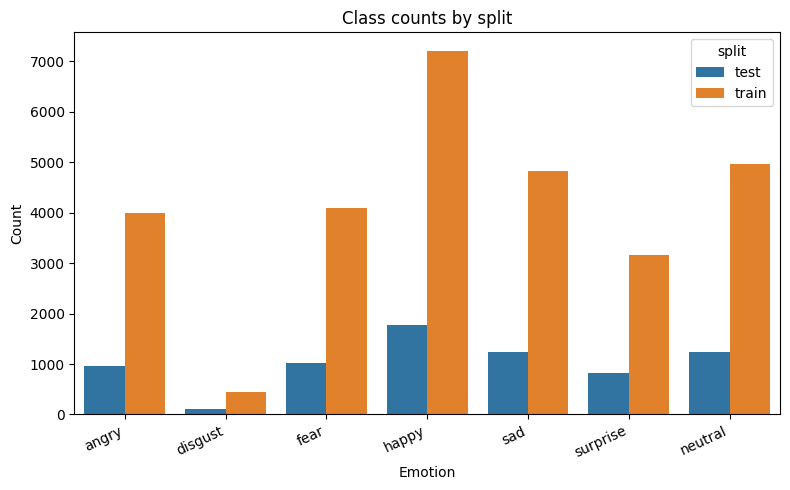

In [76]:
plt.figure(figsize=(8, 5))
sns.barplot(data=counts, x='emotion_name', y='count', hue='split', order=[EMOTION_LABELS[i] for i in range(7)])
plt.title('Class counts by split')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()


## 6. Image Format and Resolution

This check matters because pretrained models such as ResNet18 and MobileNetV2 expect larger RGB inputs, while FER2013 uses small grayscale images. This supports the input-adaptation step in the training notebook: resize 48x48 images to 224x224 and convert them to 3 channels.


In [68]:
image_rows = []
for split in ['train', 'test']:
    for emotion in EMOTION_LABELS.values():
        for image_path in (DATA_DIR / split / emotion).glob('*'):
            with Image.open(image_path) as image:
                image_rows.append({
                    'split': split,
                    'emotion_name': emotion,
                    'width': image.width,
                    'height': image.height,
                    'mode': image.mode,
                })

image_meta = pd.DataFrame(image_rows)
image_format_table = image_meta.groupby(['split', 'width', 'height', 'mode']).size().reset_index(name='count')
image_format_table


,split,width,height,mode,count
0,test,48,48,L,7178
1,train,48,48,L,28709


## 7. Image Samples and Visual Ambiguity

The sample grid is useful for qualitative reasoning. At 48x48 resolution, some expressions are subtle or visually similar, especially angry/fear/sad/neutral. This motivates augmentation, transfer learning, and confusion-matrix analysis rather than only reporting one final accuracy.


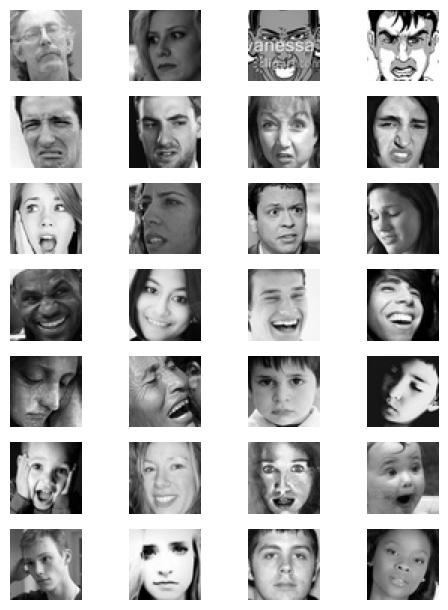

In [69]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(7, 4, figsize=(5.2, 6.2))
for label, emotion in EMOTION_LABELS.items():
    class_dir = DATA_DIR / 'train' / emotion
    all_paths = sorted(class_dir.glob('*'))
    sample_count = min(4, len(all_paths))
    sample_indices = rng.choice(len(all_paths), size=sample_count, replace=False)
    samples = [all_paths[index] for index in sample_indices]
    for ax in axes[label]:
        ax.axis('off')
    for ax, image_path in zip(axes[label], samples):
        ax.imshow(Image.open(image_path), cmap='gray')
    axes[label][0].set_ylabel(emotion, fontsize=9)
plt.tight_layout()


## 8. Optional Presentation Visuals

These plots are directly connected to model choices and are good candidates for the final presentation. Use only the ones that help your story; they are not extra required analysis.


### Class Imbalance Plot

Use this if you want one slide explaining why accuracy is not enough and why macro F1, per-class metrics, class weights, focal loss, or weighted sampling are reasonable.


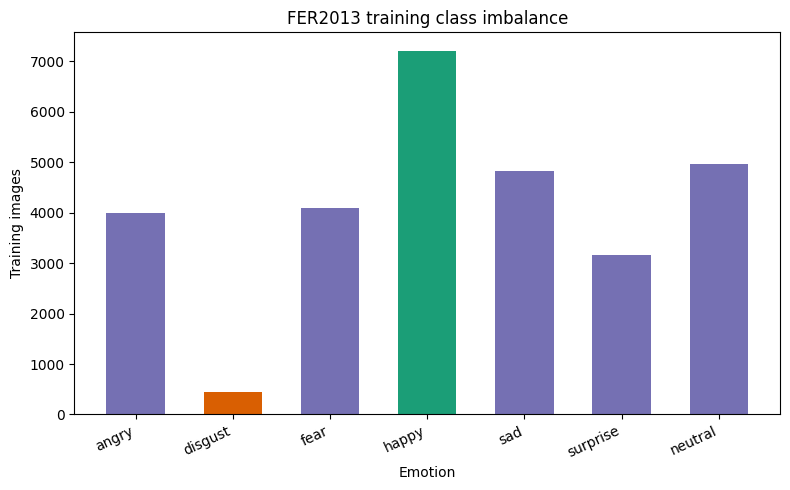

In [75]:
train_counts_ordered = counts[counts['split'] == 'train'].set_index('emotion_name').loc[[EMOTION_LABELS[i] for i in range(7)], 'count']
colors = ['#d95f02' if emotion == train_counts_ordered.idxmin() else '#1b9e77' if emotion == train_counts_ordered.idxmax() else '#7570b3' for emotion in train_counts_ordered.index]

plt.figure(figsize=(8, 5))
plt.bar(train_counts_ordered.index, train_counts_ordered.values, color=colors, width=0.6)
plt.title('FER2013 training class imbalance')
plt.xlabel('Emotion')
plt.ylabel('Training images')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()


### Representative Samples

Use this if you want to show why FER2013 is difficult: low resolution, subtle expressions, and visually similar classes.


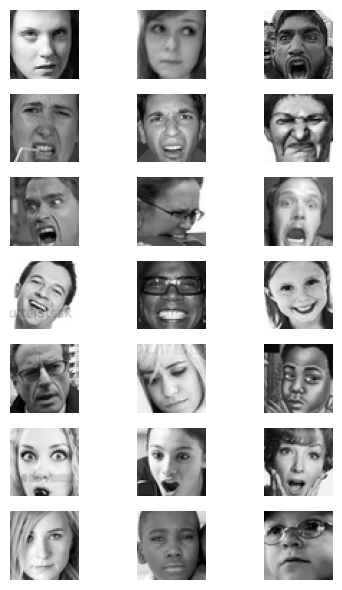

In [71]:
rng = np.random.default_rng(7)
fig, axes = plt.subplots(7, 3, figsize=(4.4, 6.0))
for label, emotion in EMOTION_LABELS.items():
    class_dir = DATA_DIR / 'train' / emotion
    all_paths = sorted(class_dir.glob('*'))
    sample_indices = rng.choice(len(all_paths), size=3, replace=False)
    samples = [all_paths[index] for index in sample_indices]
    for ax in axes[label]:
        ax.axis('off')
    for ax, image_path in zip(axes[label], samples):
        ax.imshow(Image.open(image_path), cmap='gray')
    axes[label][0].set_ylabel(emotion, fontsize=9)
plt.tight_layout()


### Augmentation Preview

Use this if you want to justify the CNN-with-augmentation experiment. The transformations are intentionally light because FER2013 labels depend on facial structure.


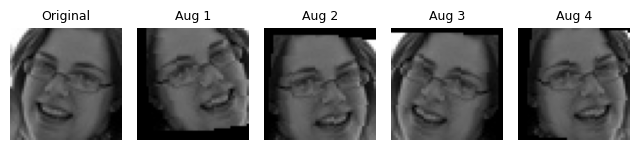

In [72]:
from torchvision import transforms

example_path = sorted((DATA_DIR / 'train' / 'happy').glob('*'))[0]
augment_preview = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
])

image = Image.open(example_path).convert('L')
rng_state = torch.random.get_rng_state() if 'torch' in globals() else None
fig, axes = plt.subplots(1, 5, figsize=(6.5, 1.7))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')
for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(augment_preview(image), cmap='gray')
    ax.set_title(f'Aug {i}', fontsize=9)
    ax.axis('off')
plt.tight_layout()


### Pretrained Input Adaptation

Use this if you discuss ResNet18 or MobileNetV2. It shows the mismatch between FER2013 and ImageNet-pretrained backbones.


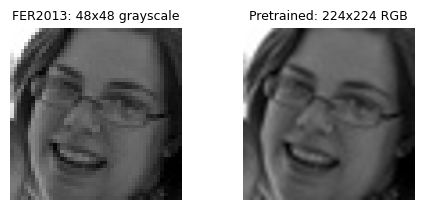

In [73]:
example_path = sorted((DATA_DIR / 'train' / 'happy').glob('*'))[0]
with Image.open(example_path).convert('L') as image:
    original = image.copy()
    resized_rgb = image.resize((224, 224)).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(4.8, 2.2))
axes[0].imshow(original, cmap='gray')
axes[0].set_title('FER2013: 48x48 grayscale', fontsize=9)
axes[0].axis('off')
axes[1].imshow(resized_rgb)
axes[1].set_title('Pretrained: 224x224 RGB', fontsize=9)
axes[1].axis('off')
plt.tight_layout()


## 9. Summary for the Experiments

The tables and plots above support the experiment design and evaluation protocol:

- FER2013 images are 48x48 grayscale, so a small CNN trained from scratch is a necessary baseline.
- The images are low-resolution and faces vary in crop/pose, so data augmentation is reasonable.
- The class distribution is imbalanced, so macro F1 should be the primary metric for model selection.
- Weighted F1 and per-class precision/recall/F1 should support the main comparison.
- Accuracy should not be used for model selection or report conclusions.
- Some expressions are visually similar, so confusion matrices and top confused pairs are needed for error analysis.
- Pretrained models require input adaptation from grayscale 48x48 to RGB 224x224. ResNet18 gives a standard transfer-learning baseline, while MobileNetV2 gives a lightweight transfer-learning comparison.
